Explainable AI-Based Loan Default Prediction

This project builds a leakage-free, interpretable credit risk model using XGBoost and SHAP.

Import Libraries

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
import shap
import matplotlib.pyplot as plt

Load Dataset

In [2]:
df = pd.read_csv("loan.csv", low_memory=False)
df = df.sample(n=200000, random_state=42)
df.shape

(200000, 145)

Target Variable Creation

In [3]:
df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])]

df['target'] = df['loan_status'].apply(
    lambda x: 1 if x == 'Charged Off' else 0
)

df['target'].value_counts()

target
0    92260
1    23067
Name: count, dtype: int64

Target:
1 = Default (Charged Off)
0 = Fully Paid

Remove Data Leakage

In [4]:
leak_cols = [
    'loan_status',
    'debt_settlement_flag',
    'total_rec_late_fee'
]

df = df.drop(columns=leak_cols, errors='ignore')

Remove High Missing Columns

In [5]:
missing_percent = df.isnull().mean() * 100
high_missing_cols = missing_percent[missing_percent > 50].index
df = df.drop(columns=high_missing_cols)

Handle Missing Values

In [6]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

df[num_cols] = df[num_cols].fillna(df[num_cols].median())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

Encode Categorical Variables

In [7]:
for col in cat_cols:
    df[col] = LabelEncoder().fit_transform(df[col])

Train-Test Split

In [8]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Baseline Model – Logistic Regression

In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression(
    max_iter=2000,
    class_weight='balanced'
)

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

print(classification_report(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(
    y_test,
    log_model.predict_proba(X_test_scaled)[:,1]
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     18366
           1       1.00      0.99      1.00      4700

    accuracy                           1.00     23066
   macro avg       1.00      1.00      1.00     23066
weighted avg       1.00      1.00      1.00     23066

ROC-AUC: 0.9998749307809759


Final Model – XGBoost

In [10]:
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_probs_xgb = xgb.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_probs_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     18366
           1       1.00      1.00      1.00      4700

    accuracy                           1.00     23066
   macro avg       1.00      1.00      1.00     23066
weighted avg       1.00      1.00      1.00     23066

ROC-AUC: 0.9999433388708553


Explainable AI – SHAP

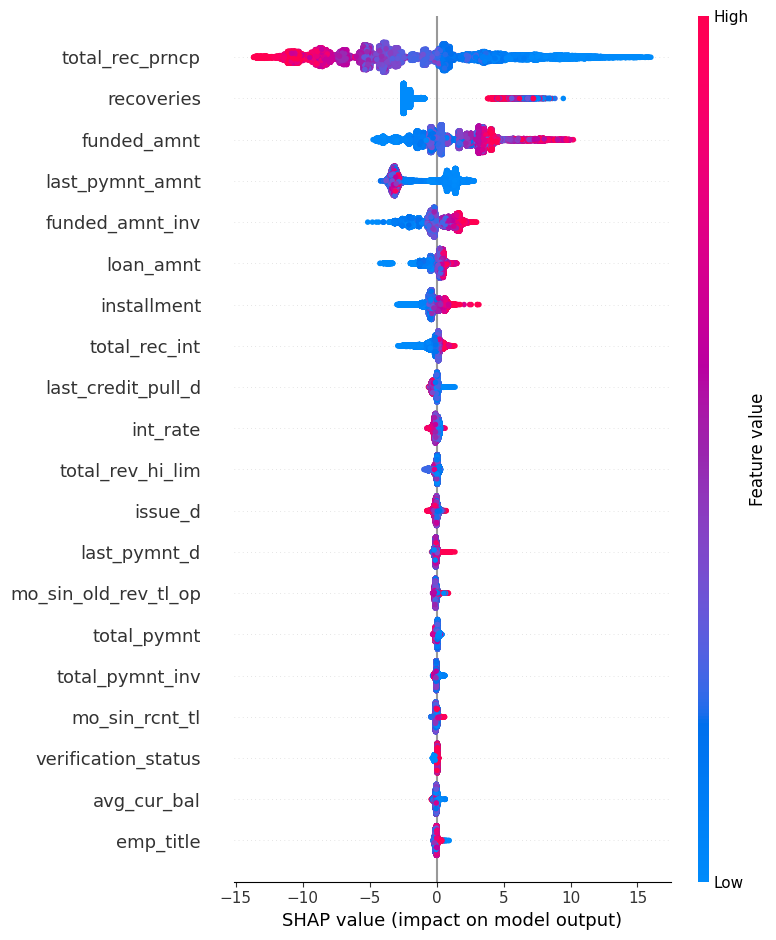

In [11]:
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)